# Lecture 2: 1D Linear Convection 

In this notebook, I solve the one-dimensional linear convection equation using a finite-difference method. 

The equation is:

$$
\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0
$$

In [3]:
import numpy as np # numerical arrays
import matplotlib.pyplot as plt  # plotting

In [ ]:
# Definition of the numerical grid

nx = 41  # number of grid points
length = 2.0  #physical length of the domain

dx = length / (nx - 1)
x = np.linspace(0, length, nx)

print("Number of grid points", nx)
print("Grid spacing dx:", dx)
print("First five x values:", x[:5])

# More grid points means a finer numerical grid 
# A finer grid usually gives better accuracy, but it costs more computation

Number of grid points 41
Grid spacing dx: 0.05
First five x values: [0.   0.05 0.1  0.15 0.2 ]


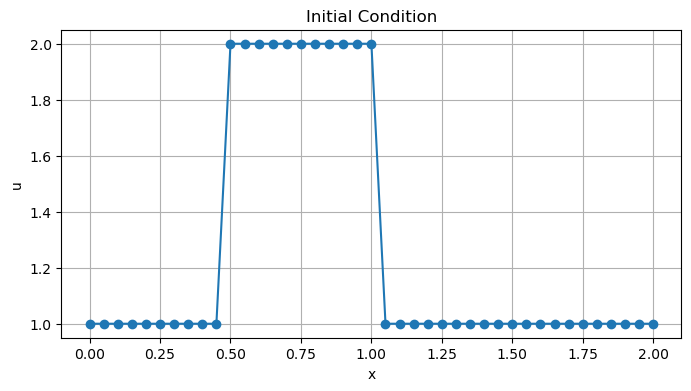

In [7]:
# Definition of the initial condition 

u_initial = np.ones(nx)
u_initial[int(0.5 / dx):int(1.0 / dx + 1)] = 2

plt.figure(figsize=(8,4))
plt.plot(x, u_initial, marker="o")
plt.xlabel("x")
plt.ylabel("u")
plt.title("Initial Condition")
plt.grid()
plt.show()

# u = 2 between x = 0.5 and x = 1.0
# u = 1 elsewhere

In [11]:
# Python concept: copying arrays 

a = np.array([1, 2, 3])
b = a.copy()

b[0] = 100

print("a = ", a)
print("b = ", b)

# Because b = a does not create a real independent copy. It only gives another name to the same array
# In CFD, we need .copy() because we must calculate the new time level using values the old time level

a =  [1 2 3]
b =  [100   2   3]


In [13]:
# for loop practise to recap in python
for i in range(5):
    print("i =", i)

i = 0
i = 1
i = 2
i = 3
i = 4


## Finite-Difference Discretization

The linear convection equation is:

$$
\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0
$$

We approximate the time derivative with a forward difference:

$$
\frac{\partial u}{\partial t} \approx \frac{u_i^{n+1} - u_i^n}{\Delta t}
$$

We approximate the spatial derivative with a backward difference:

$$
\frac{\partial u}{\partial x} \approx \frac{u_i^n - u_{i-1}^n}{\Delta x}
$$

Substituting these into the equation gives:

$$
u_i^{n+1} = u_i^n - c \frac{\Delta t}{\Delta x}
\left( u_i^n - u_{i-1}^n \right)
$$

This is called an explicit upwind scheme.

In [16]:
# Definition of simulation parameters

nt = 25  # number of time steps
dt = 0.025 # time-step size 
c = 1.0  # convection speed 

print("Number of time steps: ", nt)
print("Time step dt:", dt)
print("Convection speed c:", c)
print("CFL number:", c * dt/dx) # simple explicit method, we usually want CFL <= 1

Number of time steps:  25
Time step dt: 0.025
Convection speed c: 1.0
CFL number: 0.5


In [18]:
# Solver implementation

u = u_initial.copy()

for n in range(nt):  # outer loop: moves forward in time
    un = u.copy()    # stores old solution before updating

    for i in range(1, nx):    # Inner loop: updates every grid point
        u[i] = un[i] - c * dt / dx * (un[i] - un[i-1])    # new value = old value - wave speed effect from neighboring point

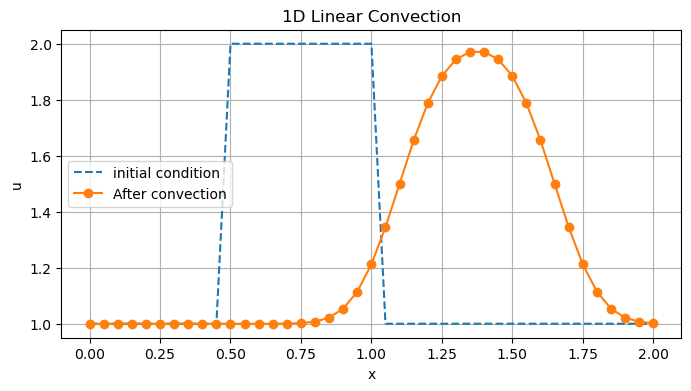

In [19]:
plt.figure(figsize = (8,4))

plt.plot(x , u_initial, label = "initial condition", linestyle = "--")
plt.plot(x, u, label = "After convection", marker = "o")

plt.xlabel("x")
plt.ylabel("u")
plt.title("1D Linear Convection")
plt.legend()
plt.grid()
plt.show()

In [30]:
# Putting the solver into a function 

def solve_linear_convection(nx = 41, nt = 25, dt = 0.025, c = 1.0, length = 2.0):
    """
    Solve the 1D linear convection equation using an explicit upwind scheme.

    Parameters
    ----------
    nx: int
        Number of grid points
    nt: init
        Number of time steps
    dt: float
        Time-step size
    c: float
        Convection speed 
    length: float
        Length of the spatial domain

    Returns
    ---------
    x: numpy.ndarray
       Spatial grid. 
    u_initial: numpy.ndarray
        Initial condition.
    u: numpy.ndarray
        Final solution after nt time steps.

    """

    dx = length / (nx - 1)
    x = np.linspace(0, length, nx)
    
    u_initial = np.ones(nx)
    u_initial[int(0.5 / dx):int(1.0 / dx + 1)] = 2
    
    u = u_initial.copy()
    
    for n in range(nt):
        un = u.copy()
        
        for i in range(1, nx):
            u[i] = un[i] - c * dt / dx * (un[i] - un[i-1])
    
    return x, u_initial, u


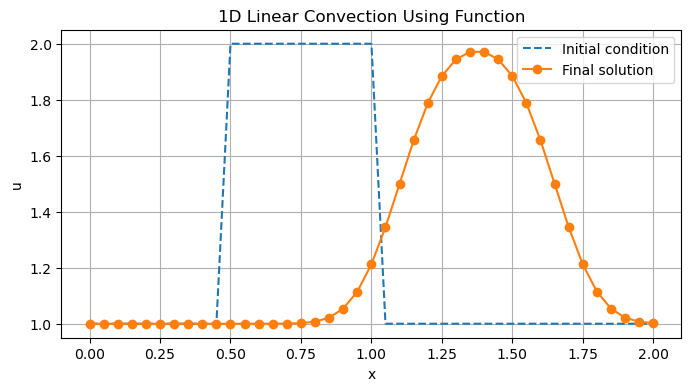

In [31]:
x, u_initial, u_final = solve_linear_convection(nx=41, nt=25, dt=0.025, c=1.0)

plt.figure(figsize=(8, 4))
plt.plot(x, u_initial, label="Initial condition", linestyle="--")
plt.plot(x, u_final, label="Final solution", marker="o")
plt.xlabel("x")
plt.ylabel("u")
plt.title("1D Linear Convection Using Function")
plt.legend()
plt.grid()
plt.show()

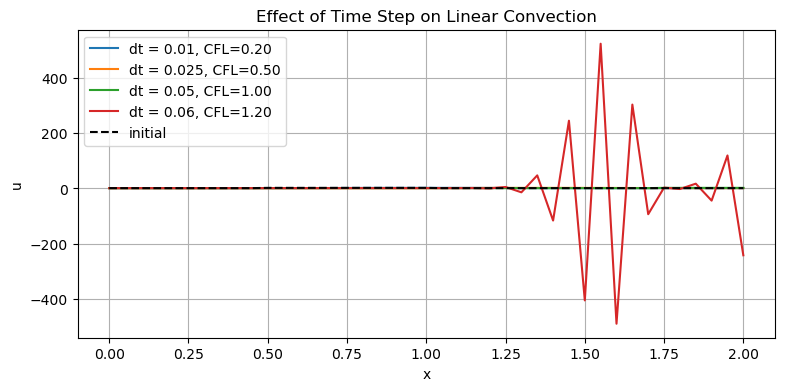

In [32]:
# Experiment with different time steps

time_steps = [0.01, 0.025, 0.05, 0.06]

plt.figure(figsize = (9,4))

for dt_test in time_steps:
    x, u_initial, u_result = solve_linear_convection(nx=41, nt=25, dt=dt_test, c=1.0)
    cfl = 1.0 * dt_test / (2.0 / (41 - 1))
    plt.plot(x, u_result, label=f"dt = {dt_test}, CFL={cfl:.2f}")

plt.plot(x, u_initial, "k--", label= "initial")
plt.xlabel("x")
plt.ylabel("u")
plt.title("Effect of Time Step on Linear Convection")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Important lesson from today
# u[i] = un[i] - c * dt/dx - (un[i] - un[i-1])

# understand deeply: to compute the new value at point i, use the old value at point i and the old value from the left neighbor.

# This is called upwind because the information comes from the upstream direction. 
# Since c > 0, the flow moves from left to right, so the upstream point is: i - 1 

# For aerospace and F1 aerodynamics, this idea matters because flow information is directional. Numerical schemes must respect the direction of propagation.

# When the CFL number exceeds 1, the chosen time step is too large for the grid spacing and wave speed. The numerical scheme becomes unstable, so the solution may diverge or show strong nonphysical oscillations.

# The linear convection equation models the transport of information in a flow field. Although simple, it introduces important CFD concepts used in more advanced aerospace and automotive aerodynamics simulations.